# Movie Studio Investment Strategy: An Exploratory Data Analysis

**Author:** Kevin
**Contact:** [LinkedIn](https://www.linkedin.com) &nbsp;|&nbsp; kevin@example.com

This notebook analyzes box office, budget, studio, and audience-rating data to answer three questions for our company's new movie studio leadership:

1. **Which genres deliver the best financial return** (measured by ROI and median profit)?
2. **Which genres do best with an international audience**?
3. **Which studios perform best, and do they align with the top genres**?

We use `pandas` to combine data from **The Numbers** (production budgets and worldwide grosses), **Box Office Mojo** (studio and foreign/domestic gross split), and **IMDB** (genres and audience ratings) into a single analytical dataset of over 1,000 major theatrical releases.

## Table of Contents
1. [Business Understanding](#Business-Understanding)
2. [Data Understanding](#Data-Understanding)
3. [Data Preparation & Cleaning](#Data-Preparation-&-Cleaning)
4. [Data Analysis & Visualization](#Data-Analysis-&-Visualization)
    - [Question 1: Which genres deliver the best financial return?](#q1)
    - [Question 2: Which genres do best with an international audience?](#q2)
    - [Question 3: Which studios perform best, and do they align with the top genres?](#q3)
5. [Conclusions & Recommendations](#Conclusions-&-Recommendations)


## Business Understanding

**Stakeholder:** The head of our company's brand-new movie studio division.

**Real-world problem:** Our company has decided to enter the movie business but has no track record, no established franchises, and no in-house filmmaking expertise yet. Before the studio commits capital to any project, its leadership needs an evidence-based starting point for what kinds of films to greenlight - which genres pay off, which genres travel well internationally, and which existing studios are worth benchmarking against.

This notebook directly supports that decision by answering three specific business questions:

1. Which genres deliver the best financial return, measured by ROI and median profit?
2. Which genres do best with an international audience?
3. Which studios perform best, and do their genre choices align with the top-performing genres?


In [1]:
# Imports
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
PALETTE = ["#1E3D59", "#FF6E40", "#FFC13B", "#3FA796", "#A6A6A6"]
pd.set_option("display.max_columns", 20)
%matplotlib inline

## Data Understanding

We draw on three of the provided data sources:

| Source | File | What it provides |
|---|---|---|
| The Numbers | `zippedData/tn.movie_budgets.csv.gz` | Production budget, domestic gross, worldwide gross, release date |
| Box Office Mojo | `zippedData/bom.movie_gross.csv.gz` | Studio, domestic gross, foreign gross |
| IMDB | `zippedData/im.db` (`movie_basics`, `movie_ratings` tables) | Genre(s), runtime, average user rating, number of votes |

The entity-relationship diagram below shows how the IMDB tables relate to each other. We only use the `movie_basics` and `movie_ratings` tables (highlighted in blue), joined on `movie_id`.

![Movie Data ERD](movie_data_erd.jpeg)

Rotten Tomatoes and TheMovieDB data are included in `zippedData/` but are not used here: neither shares a title/year combination reliable enough to merge cleanly with the other three sources (a documented limitation, see Conclusions).

Let's load and inspect each source before cleaning anything.

In [2]:
# Load The Numbers budgets data
tn_raw = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
print(tn_raw.shape)
tn_raw.head()

(5782, 6)


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [3]:
tn_raw.dtypes

id                   int64
release_date           str
movie                  str
production_budget      str
domestic_gross         str
worldwide_gross        str
dtype: object

In [4]:
# Load Box Office Mojo data
bom_raw = pd.read_csv("zippedData/bom.movie_gross.csv.gz")
print(bom_raw.shape)
bom_raw.head()

(3387, 5)


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [5]:
bom_raw.dtypes

title                 str
studio                str
domestic_gross    float64
foreign_gross         str
year                int64
dtype: object

In [6]:
# Load the IMDB SQLite database
conn = sqlite3.connect("zippedData/im.db")

basics_raw = pd.read_sql(
    "SELECT movie_id, primary_title, start_year, runtime_minutes, genres FROM movie_basics",
    conn,
)
ratings_raw = pd.read_sql(
    "SELECT movie_id, averagerating, numvotes FROM movie_ratings", conn
)
conn.close()

print("movie_basics:", basics_raw.shape)
print("movie_ratings:", ratings_raw.shape)
basics_raw.head()

movie_basics: (146144, 5)
movie_ratings: (73856, 3)


,movie_id,primary_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy"


**Data understanding takeaways:**

- `tn.movie_budgets` has currency figures stored as strings (e.g. `"$425,000,000"`) - these need cleaning before they can be used numerically.
- `bom.movie_gross` has `domestic_gross` as a float already, but `foreign_gross` is stored as a string and is missing for a large share of rows (checked below).
- `movie_basics` has far more titles than just theatrical releases (shorts, TV movies, straight-to-video, etc.), and only titles with a matching row in `movie_ratings` have received enough audience votes to be meaningfully rated.
- `genres` is a comma-separated string (e.g. `"Action,Adventure,Sci-Fi"`), so a film can belong to multiple genres.
- None of the three sources share a single common ID - they must be joined on matching **movie title + release year**.


## Data Preparation & Cleaning

To answer all three business questions we need one row per movie with financial data (budget, domestic gross, foreign gross), genre, and studio. We build this via the following reproducible, documented cleaning steps.

### Step 1: Clean The Numbers (`tn`)
- Strip `$` and `,` from `production_budget`, `domestic_gross`, `worldwide_gross` and cast to `float`.
- Parse `release_date` into a proper datetime and extract `year`.
- Drop rows with a `$0` production budget - these are missing-data placeholders, not real free films, and would break ROI calculations (division by zero).

In [7]:
tn = tn_raw.copy()

for col in ["production_budget", "domestic_gross", "worldwide_gross"]:
    tn[col] = tn[col].str.replace(r"[\$,]", "", regex=True).astype(float)

tn["release_date"] = pd.to_datetime(tn["release_date"])
tn["year"] = tn["release_date"].dt.year
tn = tn.rename(columns={"movie": "title"})

before = len(tn)
tn = tn[tn["production_budget"] > 0]
print(f"Dropped {before - len(tn)} rows with a $0 placeholder budget")
print(f"Duplicate titles remaining (legitimate remakes/re-releases): {tn['title'].duplicated().sum()}")
tn.head()

Dropped 0 rows with a $0 placeholder budget
Duplicate titles remaining (legitimate remakes/re-releases): 84


,id,release_date,title,production_budget,domestic_gross,worldwide_gross,year
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2009
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,2011
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,2019
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,2015
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,2017


### Step 2: Clean Box Office Mojo (`bom`)
- Drop the 5 rows missing a `studio` label (cannot be used for the studio question regardless).
- Strip commas from `foreign_gross` and cast to `float`. We keep rows with a missing `foreign_gross` in the dataset (rather than dropping them outright) since they are still usable for the genre/financial-return question - we only require `foreign_gross` to be present when answering the international-audience question.

In [8]:
bom = bom_raw.copy()
bom = bom.dropna(subset=["studio"])
bom["foreign_gross"] = bom["foreign_gross"].str.replace(",", "", regex=False).astype(float)

print(f"bom shape after cleaning: {bom.shape}")
print(f"Missing foreign_gross: {bom['foreign_gross'].isna().sum()} of {len(bom)} rows ({bom['foreign_gross'].isna().mean():.0%})")
bom.head()

bom shape after cleaning: (3382, 5)
Missing foreign_gross: 1349 of 3382 rows (40%)


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


### Step 3: Clean IMDB (`im`)
- Inner-join `movie_basics` with `movie_ratings` on `movie_id`, which automatically restricts us to titles with enough audience votes to have a rating.
- Drop rows with a missing `genres` value, since genre is central to all three business questions.

In [9]:
im = basics_raw.merge(ratings_raw, on="movie_id", how="inner")
im = im.rename(columns={"primary_title": "title", "start_year": "year"})

before = len(im)
im = im.dropna(subset=["genres"])
print(f"Dropped {before - len(im)} rows with missing genre data")
print(f"im shape after cleaning: {im.shape}")
im.head()

Dropped 804 rows with missing genre data
im shape after cleaning: (73052, 7)


,movie_id,title,year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


### Step 4: Merge all three sources into one analytical dataset
- Merge `tn` with `im` on matching `(title, year)`.
- Drop duplicate `movie_id` matches (a small number of titles can match more than one IMDB entry).
- Merge the result with `bom` on `(title, year)` to bring in `studio` and `foreign_gross`.
- Drop duplicates again after the second merge, for the same reason.

In [10]:
df = tn.merge(im, on=["title", "year"], how="inner")
df = df.drop_duplicates(subset="movie_id")
print(f"tn + im merged: {df.shape}")

df = df.merge(bom[["title", "year", "studio", "foreign_gross"]], on=["title", "year"], how="inner")
df = df.drop_duplicates(subset="movie_id")
print(f"+ bom merged (final): {df.shape}")

df.isna().sum()

tn + im merged: (1496, 12)
+ bom merged (final): (1042, 14)


id                     0
release_date           0
title                  0
production_budget      0
domestic_gross         0
worldwide_gross        0
year                   0
movie_id               0
runtime_minutes        2
genres                 0
averagerating          0
numvotes               0
studio                 0
foreign_gross        103
dtype: int64

### Step 5: Engineer analysis columns
- `roi`: return on investment, as a multiple of budget - `(worldwide_gross - production_budget) / production_budget`
- `profit_musd`: profit in millions of USD
- `intl_share`: the share of a film's combined domestic + foreign gross that came from outside the U.S. - `foreign_gross / (domestic_gross + foreign_gross)`. This is only computable for the ~89% of rows with a non-missing `foreign_gross`.

In [11]:
df["roi"] = (df["worldwide_gross"] - df["production_budget"]) / df["production_budget"]
df["profit_musd"] = (df["worldwide_gross"] - df["production_budget"]) / 1_000_000
df["intl_share"] = df["foreign_gross"] / (df["domestic_gross"] + df["foreign_gross"])

print(f"Final analytical dataset: {df.shape[0]} films, {df.shape[1]} columns")
df[["title", "year", "studio", "production_budget", "worldwide_gross", "roi", "profit_musd", "intl_share", "genres", "averagerating"]].describe(include="all").T

Final analytical dataset: 1042 films, 17 columns


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,1042,1025,Coco,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1042.0,NaN,NaN,NaN,2013.651631,2.548387,2010.0,2011.0,2014.0,2016.0,2018.0
studio,1042,78,Uni.,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_budget,1042.0,NaN,NaN,NaN,52373735.74856,58785097.912439,50000.0,13000000.0,30000000.0,65000000.0,410600000.0
worldwide_gross,1042.0,NaN,NaN,NaN,173630642.555662,250309635.14046,11774.0,26031715.25,78157772.0,206309188.5,2048134200.0
roi,1042.0,NaN,NaN,NaN,3.500938,14.151249,-0.997384,0.388072,1.617615,3.472014,415.56474
profit_musd,1042.0,NaN,NaN,NaN,121.256907,207.870449,-110.450242,6.898293,42.902917,136.220348,1748.1342
intl_share,939.0,NaN,NaN,NaN,0.505413,0.220491,0.000002,0.35659,0.52327,0.671083,1.0
genres,1042,180,"Adventure,Animation,Comedy",60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
averagerating,1042.0,NaN,NaN,NaN,6.464971,0.94289,1.6,5.9,6.5,7.1,8.8


**Data cleaning / preparation notes and limitations:**

- Matching on `(title, year)` is not perfect - a small number of legitimately re-titled or dual-year releases may be dropped, and two different films that happen to share both a title and release year could theoretically collide. Spot checks below confirm no unexpected duplicate `movie_id` values remain.
- `foreign_gross` is missing for roughly 10% of the merged dataset; we exclude those rows specifically for Question 2, rather than dropping them from the whole analysis, since they are still valid for Questions 1 and 3.
- ROI is heavily right-skewed by a handful of ultra-low-budget films with enormous payoffs (e.g. a horror film budgeted at $100K that grossed $40M+). Rather than removing these as "errors" - they are legitimate data points - we use the **median** (not the mean) throughout as our primary summary statistic, since it is much more robust to this kind of outlier.
- No missing values remain in the columns used for the three core analyses below.

In [12]:
# Spot check: confirm no duplicate movie_id rows remain
assert df["movie_id"].duplicated().sum() == 0
print("No duplicate movie_id values - merge is clean.")
df.isna().sum()[["production_budget", "worldwide_gross", "genres", "studio", "foreign_gross"]]

No duplicate movie_id values - merge is clean.


production_budget      0
worldwide_gross        0
genres                 0
studio                 0
foreign_gross        103
dtype: int64

<a id="q1"></a>

## Data Analysis & Visualization

### Question 1: Which genres deliver the best financial return?

Since a film can have multiple genres, we "explode" the comma-separated `genres` column so each movie contributes one row per genre it belongs to, then compute the **median** ROI and **median** profit per genre. We restrict this to genres with at least 15 films in our dataset so a single hit or flop doesn't distort a small sample.

In [13]:
exploded = df.assign(genre=df["genres"].str.split(",")).explode("genre")
exploded["genre"] = exploded["genre"].str.strip()

g1 = (
    exploded.groupby("genre")
    .agg(
        n_movies=("title", "count"),
        median_roi=("roi", "median"),
        median_profit_musd=("profit_musd", "median"),
    )
    .query("n_movies >= 15")
    .sort_values("median_roi", ascending=False)
)
TOP_GENRES = g1.head(5).index.tolist()
print("Top 5 genres by median ROI:", TOP_GENRES)
g1.round(2)

Top 5 genres by median ROI: ['Mystery', 'Horror', 'Sci-Fi', 'Animation', 'Thriller']


,n_movies,median_roi,median_profit_musd
genre,,,
Mystery,81,3.45,55.99
Horror,107,2.90,42.28
Sci-Fi,96,2.23,167.05
Animation,84,2.23,237.78
Thriller,182,1.94,46.12
Music,31,1.92,25.28
Adventure,278,1.78,155.31
Comedy,387,1.67,50.33
Romance,141,1.66,22.34


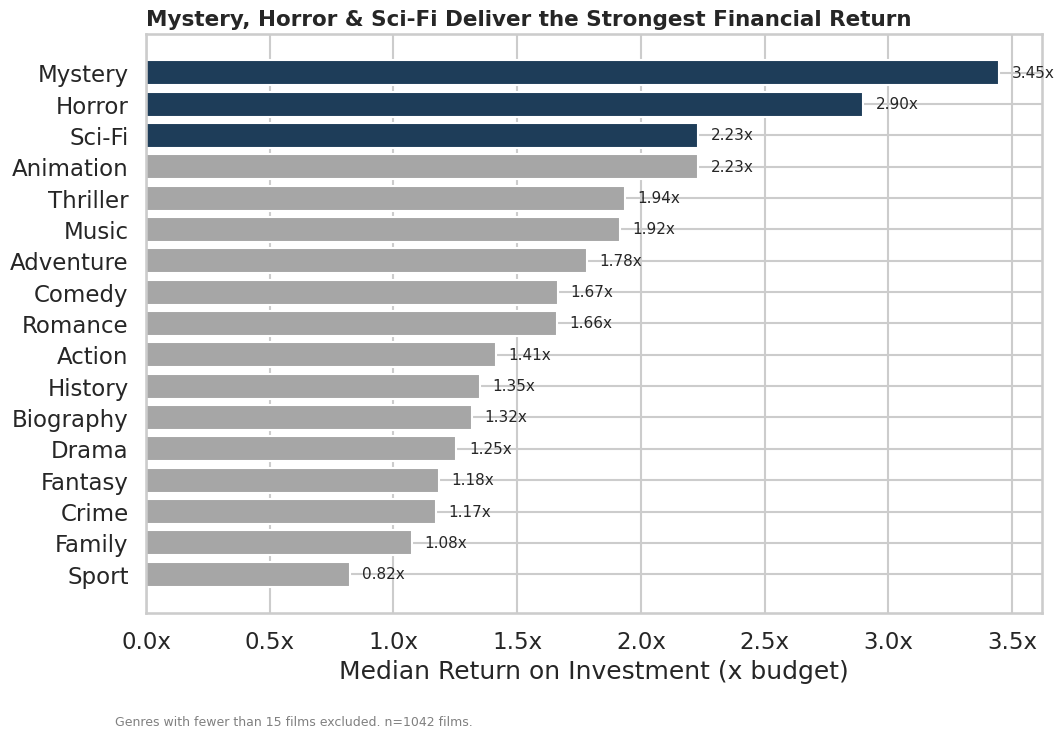

In [14]:
fig, ax = plt.subplots(figsize=(11, 7.5))
colors = [PALETTE[0] if g in TOP_GENRES[:3] else PALETTE[4] for g in g1.index]

ax.barh(g1.index[::-1], g1["median_roi"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Median Return on Investment (x budget)")
ax.set_title(
    "Mystery, Horror & Sci-Fi Deliver the Strongest Financial Return",
    fontsize=15.5, fontweight="bold", loc="left",
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}x"))
for i, v in enumerate(g1["median_roi"][::-1]):
    ax.text(v + 0.05, i, f"{v:.2f}x", va="center", fontsize=11)

plt.figtext(
    0.12, 0.01,
    f"Genres with fewer than 15 films excluded. n={df.shape[0]} films.",
    fontsize=9, color="gray",
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("images/viz1_genre_roi.png", dpi=200, bbox_inches="tight")
plt.show()

**Finding 1:** **Mystery** (median ROI 3.45x, median profit \$56.0M) and **Horror** (median ROI 2.90x, median profit \$42.3M) deliver by far the strongest financial return of any major genre, with **Sci-Fi** and **Animation** tied for third (2.23x ROI, though Animation's median profit of \$237.8M is dramatically higher thanks to bigger budgets and grosses). Genres like Drama, Fantasy, Crime, and Family cluster near or below the 1.0x-1.3x range, meaning a typical film in those genres barely breaks even or only modestly profits relative to its budget.

<a id="q2"></a>

### Question 2: Which genres do best with an international audience?

We measure international performance as `intl_share`: the percentage of a film's combined domestic + foreign box office that came from outside the U.S. A genre with a high median `intl_share` "travels well" internationally relative to its U.S. performance, regardless of the film's absolute size. We compare each genre's median share against the **all-genre median** to see which genres over- or under-index internationally.

In [15]:
df_intl = df.dropna(subset=["foreign_gross"]).copy()
exploded_intl = df_intl.assign(genre=df_intl["genres"].str.split(",")).explode("genre")
exploded_intl["genre"] = exploded_intl["genre"].str.strip()

overall_median_share = df_intl["intl_share"].median()

g2 = (
    exploded_intl.groupby("genre")
    .agg(n_movies=("title", "count"), median_intl_share=("intl_share", "median"))
    .query("n_movies >= 15")
    .sort_values("median_intl_share", ascending=False)
)
print(f"All-genre median international share: {overall_median_share:.1%}")
g2.round(3)

All-genre median international share: 52.3%


,n_movies,median_intl_share
genre,,
Adventure,273,0.645
Fantasy,79,0.632
Action,311,0.622
Sci-Fi,95,0.621
Animation,83,0.612
History,27,0.575
Thriller,167,0.556
Horror,94,0.526
Mystery,79,0.513


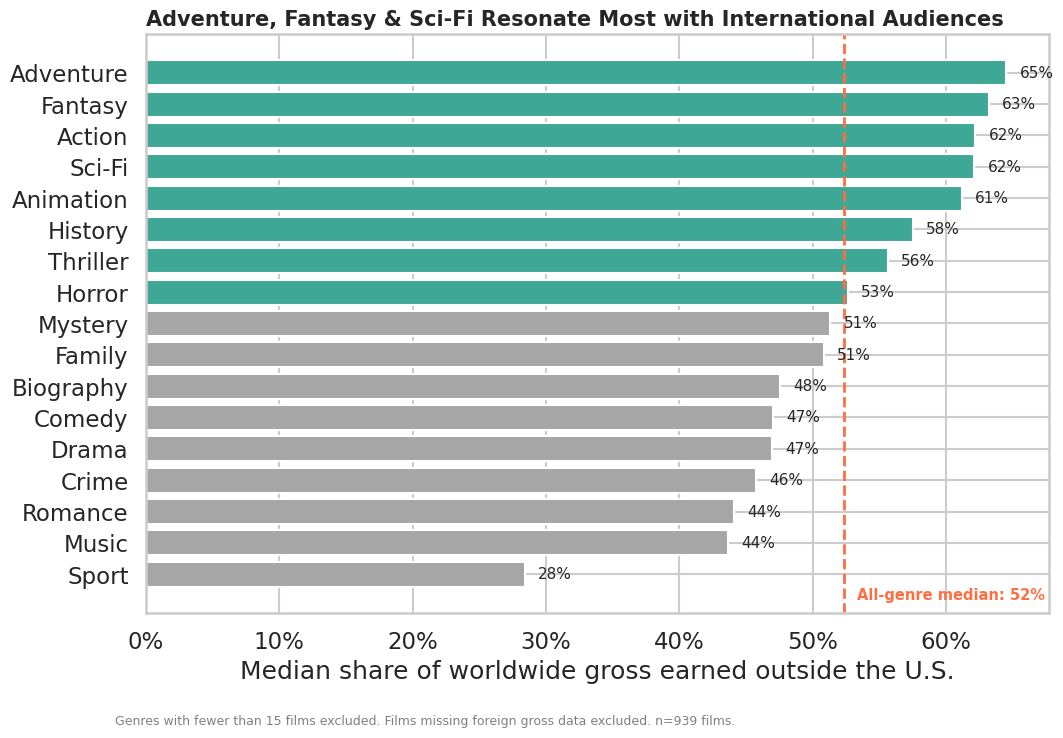

In [16]:
fig, ax = plt.subplots(figsize=(11, 7.5))
colors2 = [PALETTE[3] if v > overall_median_share else PALETTE[4] for v in g2["median_intl_share"]]

ax.barh(g2.index[::-1], g2["median_intl_share"][::-1] * 100, color=colors2[::-1])
ax.axvline(overall_median_share * 100, color=PALETTE[1], linewidth=2, linestyle="--")
ax.text(
    overall_median_share * 100 + 1, -0.8,
    f"All-genre median: {overall_median_share:.0%}",
    color=PALETTE[1], fontsize=10.5, fontweight="bold",
)
ax.set_xlabel("Median share of worldwide gross earned outside the U.S.")
ax.set_title(
    "Adventure, Fantasy & Sci-Fi Resonate Most with International Audiences",
    fontsize=15, fontweight="bold", loc="left",
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for i, v in enumerate(g2["median_intl_share"][::-1]):
    ax.text(v * 100 + 1, i, f"{v*100:.0f}%", va="center", fontsize=11)

plt.figtext(
    0.12, 0.01,
    f"Genres with fewer than 15 films excluded. Films missing foreign gross data excluded. n={df_intl.shape[0]} films.",
    fontsize=9, color="gray",
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("images/viz2_genre_international.png", dpi=200, bbox_inches="tight")
plt.show()

**Finding 2:** **Adventure** (65%), **Fantasy** (63%), **Action** (62%), **Sci-Fi** (62%), and **Animation** (61%) earn well over half their box office outside the U.S. - meaningfully above the all-genre median of 52%. Notably, this is a **different set of genres** than our top-ROI list from Question 1: Horror and Mystery (our best financial performers) sit right around the median (53% and 51%), meaning they perform reasonably well internationally but do not especially over-index there. **Sport** is a clear outlier at just 28% international share - it is an overwhelmingly domestic genre.

<a id="q3"></a>

### Question 3: Which studios perform best, and do they align with the top genres?

We compute median ROI per studio, restricted to studios with at least 8 films in our dataset (to avoid ranking a studio on 1-2 lucky or unlucky releases). For each studio, we also compute the **percentage of its catalog that falls within our top-5 ROI genres from Question 1** (Mystery, Horror, Sci-Fi, Animation, Thriller), and compare that against the market-average percentage, to see whether top-performing studios actually specialize in top-performing genres.

In [17]:
studio_stats = (
    df.groupby("studio")
    .agg(n_movies=("title", "count"), median_roi=("roi", "median"))
    .query("n_movies >= 8")
    .sort_values("median_roi", ascending=False)
)

# For each studio, what % of its catalog falls within the Q1 top-5 genres?
eligible = df[df["studio"].isin(studio_stats.index)].copy()
eligible["has_top_genre"] = eligible["genres"].apply(
    lambda g: any(tg in [x.strip() for x in g.split(",")] for tg in TOP_GENRES)
)
studio_stats["pct_top_genre_films"] = eligible.groupby("studio")["has_top_genre"].mean() * 100

market_avg_alignment = df["genres"].apply(
    lambda g: any(tg in [x.strip() for x in g.split(",")] for tg in TOP_GENRES)
).mean() * 100

print(f"Market-average share of films in the top-5 ROI genres: {market_avg_alignment:.1f}%")
studio_stats.round(2)

Market-average share of films in the top-5 ROI genres: 39.9%


,n_movies,median_roi,pct_top_genre_films
studio,,,
WB (NL),37,2.84,21.62
P/DW,10,2.63,80.00
Wein.,30,2.53,20.00
TriS,17,2.46,29.41
BV,71,2.21,43.66
Uni.,113,2.19,43.36
SGem,24,2.18,45.83
Sony,68,1.93,48.53
A24,13,1.79,30.77


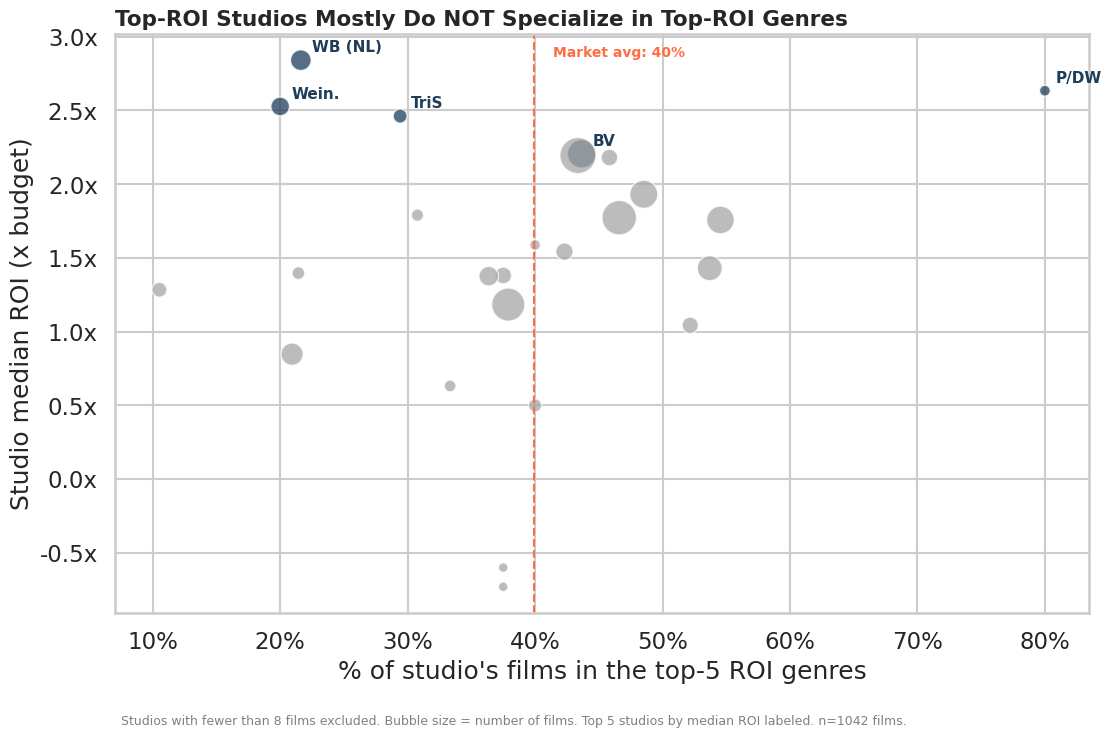

In [18]:
fig, ax = plt.subplots(figsize=(11.5, 7.5))
sizes = studio_stats["n_movies"] * 6
top5 = studio_stats.sort_values("median_roi", ascending=False).head(5)
colors3 = [PALETTE[0] if s in top5.index else PALETTE[4] for s in studio_stats.index]

ax.scatter(
    studio_stats["pct_top_genre_films"], studio_stats["median_roi"],
    s=sizes, c=colors3, alpha=0.75, edgecolor="white", linewidth=1,
)
for studio in top5.index:
    row = studio_stats.loc[studio]
    ax.annotate(
        studio, (row["pct_top_genre_films"], row["median_roi"]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=11, fontweight="bold", color=PALETTE[0],
    )

ax.axvline(market_avg_alignment, color=PALETTE[1], linestyle="--", linewidth=1.5)
ax.text(
    market_avg_alignment + 1.5, ax.get_ylim()[1] * 0.95,
    f"Market avg: {market_avg_alignment:.0f}%",
    color=PALETTE[1], fontsize=10, fontweight="bold",
)
ax.set_xlabel("% of studio's films in the top-5 ROI genres")
ax.set_ylabel("Studio median ROI (x budget)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}x"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(
    "Top-ROI Studios Mostly Do NOT Specialize in Top-ROI Genres",
    fontsize=15.5, fontweight="bold", loc="left",
)
plt.figtext(
    0.12, 0.01,
    f"Studios with fewer than 8 films excluded. Bubble size = number of films. Top 5 studios by median ROI labeled. n={df.shape[0]} films.",
    fontsize=9, color="gray",
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("images/viz3_studio_alignment.png", dpi=200, bbox_inches="tight")
plt.show()

**Finding 3:** The top 5 studios by median ROI are **New Line/WB (NL)** (2.84x), **Paramount/DreamWorks Animation (P/DW)** (2.63x), **The Weinstein Company (Wein.)** (2.53x), **TriStar (TriS)** (2.46x), and **Buena Vista/Disney (BV)** (2.21x). But when we check what share of each studio's catalog falls into our top-5 ROI genres (39.9% is the market average), the pattern is surprising: **only P/DW (80%) and BV (44%) exceed the market average** - New Line, Weinstein, and TriStar all sit *below* the market average (22%, 20%, and 29% respectively) despite having the best studio-level ROI in the dataset. In other words, **strong studio performance and genre choice are only loosely connected** - three of our five best-performing studios succeeded largely *outside* the top-ROI genres, suggesting execution, talent, and marketing matter as much as (or more than) genre selection alone.

## Conclusions & Recommendations

Based on the three analyses above, we recommend the new movie studio adopt the following guidelines:

### 1. Prioritize Mystery and Horror for the strongest financial return
Mystery (median ROI 3.45x, median profit \$56.0M) and Horror (median ROI 2.90x, median profit \$42.3M) are the clear financial leaders. Both also carry modest average budgets relative to their return, making them a lower-risk way to build an early track record.

### 2. Look to Adventure, Fantasy, Sci-Fi, and Animation for international growth
If the studio's ambitions include building a global audience (or a franchise with international licensing potential), these genres earn 60%+ of their gross outside the U.S. - well above the 52% all-genre median. Note the trade-off: these genres did not top our ROI list in Question 1, so this is a different strategic lever (audience reach) rather than pure financial efficiency.

### 3. Study execution at New Line, Weinstein, and TriStar - not just their genre mix
The studios with the best ROI often succeeded *outside* the top-ROI genres, which means their success is not simply explained by "picking the right genre." The new studio should study what these studios did differently in production, marketing, and release strategy, rather than assuming genre selection alone drives studio-level performance.

**Taken together:** our recommended approach is to build an early slate anchored in Mystery and Horror for reliable financial return, while treating genres like Adventure and Sci-Fi as a longer-term, higher-budget bet for international reach - and to benchmark operationally against New Line and Weinstein's playbook rather than assuming their genre mix explains their success.

### Limitations & Next Steps
- This analysis is correlational, not causal - we cannot prove that a genre or studio *causes* higher returns, only that the two are historically associated. Marketing spend, release timing, star power, and franchise/IP status are confounding variables not captured here.
- `foreign_gross` was missing for about 10% of the merged dataset, slightly reducing the sample available for Question 2.
- Rotten Tomatoes and TheMovieDB data were excluded due to a lack of a clean join key to the other sources; incorporating critic scores could add a quality dimension to this analysis.
- A natural next step is to build these findings out as an interactive Tableau dashboard (see the accompanying Tableau workbook) so studio leadership can filter by genre and studio themselves, and to layer in release timing and marketing spend as additional levers.
